In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
from glob import glob
import librosa 
import librosa.display
import IPython.display as ipd
from itertools import cycle
from sklearn.preprocessing import StandardScaler 
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing

# Audio Feature Extraction 

In [3]:
audio_files = glob('../input/gtzan-dataset-music-genre-classification/Data/genres_original/*/*.wav')
print(type(audio_files))
ipd.Audio(audio_files[120]) #display module for audio files

<class 'list'>


In [4]:
Y, sample_rate = librosa.load(audio_files[0])
print(f"Output Y or the raw data of audio file: ", Y)
print(Y.shape)
print("Data type: ", type(Y))
print("Sample rate: ", sample_rate)
print("Data type: ", type(sample_rate))

Output Y or the raw data of audio file:  [-0.0196228  -0.00567627  0.00927734 ...  0.01547241  0.01220703
  0.0319519 ]
(661794,)
Data type:  <class 'numpy.ndarray'>
Sample rate:  22050
Data type:  <class 'int'>


<class 'pandas.core.series.Series'>


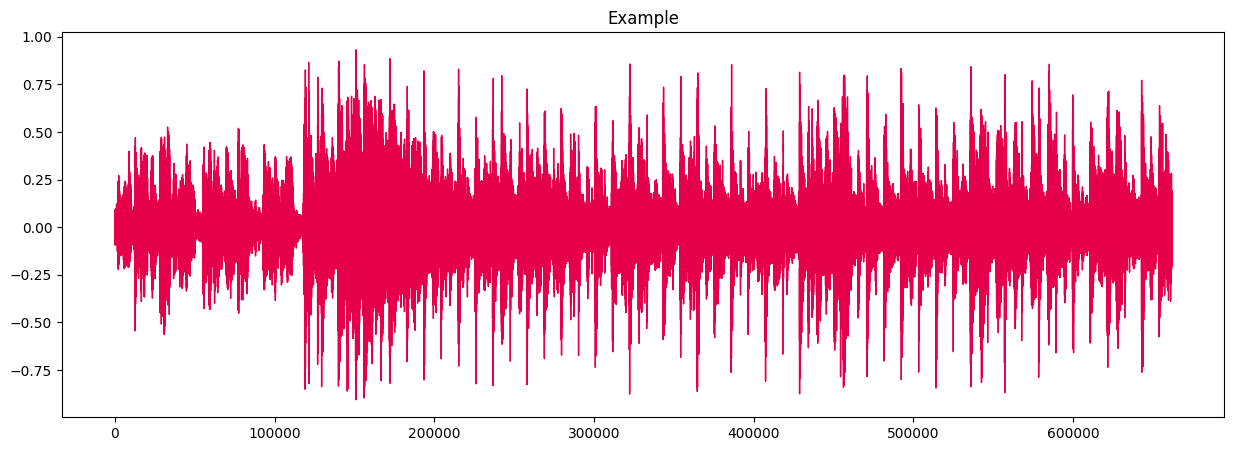

In [5]:
audio_example_1=pd.Series(Y) #converting into panda series
print(type(audio_example_1))
audio_example_1.plot(figsize=(15,5), lw=1, title="Example", color='#e60049')
plt.show()

<class 'pandas.core.series.Series'>


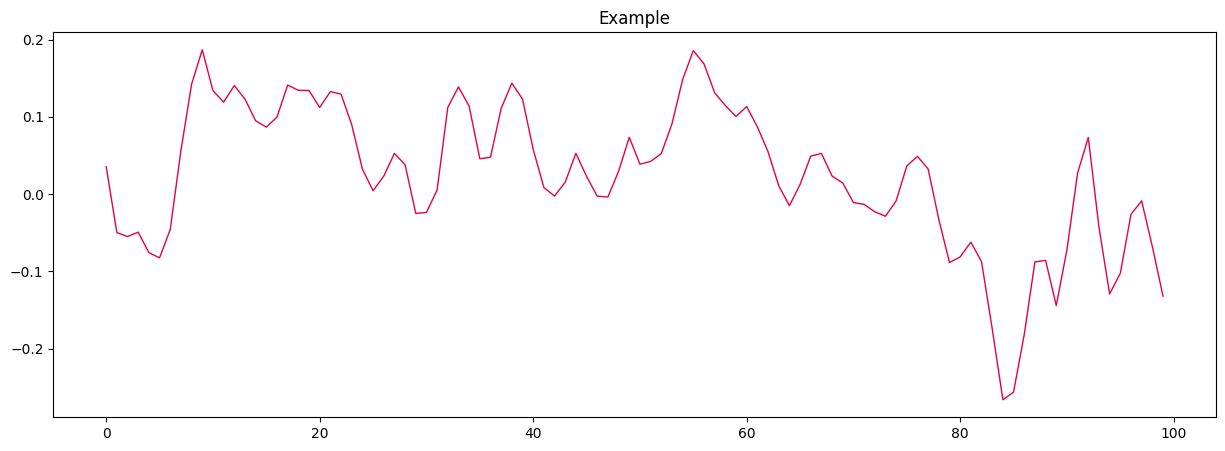

In [6]:
#zoomed in version of the same plot
audio_example_2=pd.Series(Y[450000:450100]) #converting into panda series
print(type(audio_example_2))
audio_example_2.plot(figsize=(15,5), lw=1, title="Example", color='#e60049')
plt.show()

# Short Time Fourier Transform

In [7]:
audio_stft = librosa.stft(Y)
print("Short Time Fourier Transform:\n", audio_stft)
audio_db = librosa.amplitude_to_db(np.abs(audio_stft), ref=np.max) #amplitude to decibel conversion
print("To decibel:\n", audio_db)
print(audio_db.shape)

Short Time Fourier Transform:
 [[-3.64083767e-01+0.j         -1.02356625e+00+0.j
  -1.32638574e+00+0.j         ...  8.52454782e-01+0.j
   7.72957146e-01+0.j         -1.02119155e-01+0.j        ]
 [ 8.89167562e-02-0.21539626j  5.58507264e-01-0.42969063j
   8.79648626e-01+0.12415457j ... -6.25416875e-01+0.3799517j
  -6.20893240e-01-0.46557269j  2.36817241e-01-0.40729073j]
 [ 7.63868317e-02-0.06299426j -7.05204159e-02+0.26639724j
  -1.85080618e-01-0.05805372j ... -2.27359742e-01-0.29856393j
   1.59493223e-01+0.59178597j  4.48004529e-02+0.15047392j]
 ...
 [-1.33476518e-02-0.00512429j  5.42186573e-02+0.00420348j
  -6.57283217e-02+0.00751903j ... -3.44856799e-01-0.12551744j
   1.43906534e-01+0.46393484j  2.00872377e-01+0.09711799j]
 [-1.18520588e-03-0.01930016j -3.73144075e-02+0.00644308j
   5.49421832e-03-0.01356367j ...  7.45548844e-01-0.02494809j
  -4.64986637e-02-0.75716126j -7.37847209e-01-0.05855094j]
 [ 2.19271109e-02+0.j          3.67761739e-02+0.j
   3.98905165e-02+0.j         ... -7

# Spectrogram

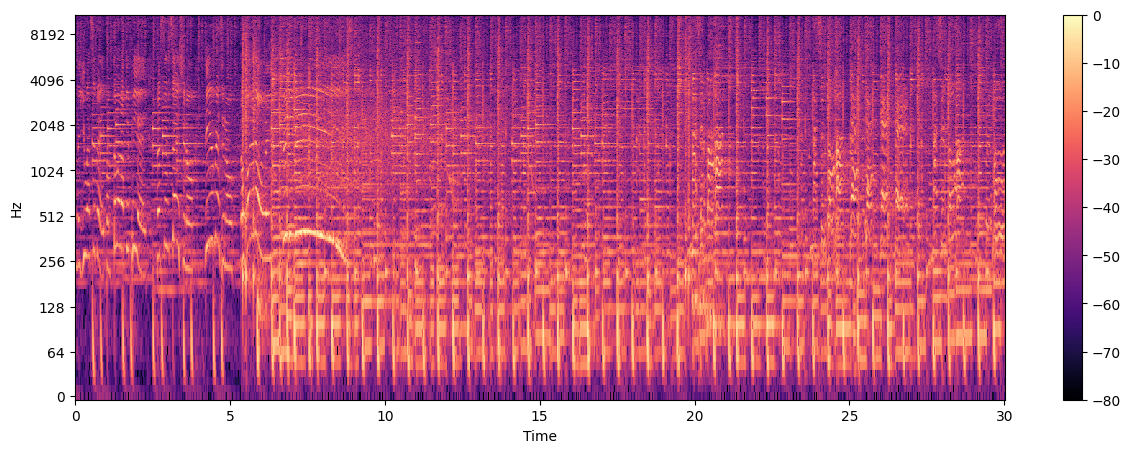

In [8]:
fig, axis = plt.subplots(figsize=(15,5))
img = librosa.display.specshow(audio_db,
                              x_axis='time',
                              y_axis='log',
                              ax=axis) #shows how diff freq change their intensities over time
fig.colorbar(img, ax=axis)
plt.show()

In [9]:
melspec = librosa.feature.melspectrogram(y=Y, sr=sample_rate, n_mels=128)
print(melspec.shape)
print(melspec)

(128, 1293)
[[3.2398393e-03 1.1753131e-02 1.4483315e-02 ... 4.6700638e-02
  2.7397843e-02 2.0941494e-02]
 [1.5368294e-02 2.1658219e-02 2.5884965e-02 ... 9.8594584e-02
  7.5719543e-02 6.9227800e-02]
 [4.2330597e-02 4.9473189e-02 3.1297933e-02 ... 2.2580411e+00
  1.8711390e+00 4.7579244e-01]
 ...
 [9.4862201e-04 1.0505154e-03 2.5966456e-03 ... 6.0097132e-02
  4.4285085e-02 3.6749467e-02]
 [4.8616729e-04 8.0274511e-04 2.8828715e-03 ... 4.5549087e-02
  3.6423232e-02 2.2735255e-02]
 [4.2120140e-04 9.0438727e-04 2.8814487e-03 ... 3.2867584e-02
  3.4648344e-02 2.8188473e-02]]


# MEL Spectrogram

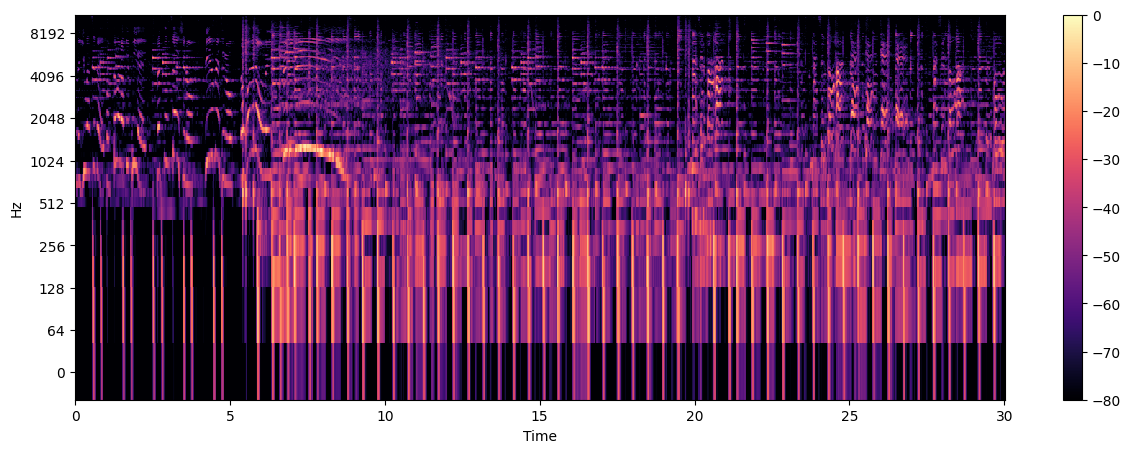

In [10]:
melspec_db = librosa.amplitude_to_db(np.abs(melspec), ref=np.max)
fig, axis = plt.subplots(figsize=(15,5))
img = librosa.display.specshow(melspec_db,
                              x_axis='time',
                              y_axis='log',
                              ax=axis) #shows how diff freq change their intensities over time
fig.colorbar(img, ax=axis)
plt.show()

# Some Machine Learning Algorithms 

In [11]:
data = pd.read_csv(f"/kaggle/input/gtzan-dataset-music-genre-classification/Data/features_3_sec.csv", index_col='filename')
data

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
filename,,,,,,,,,,,,,,,,,,,,,
blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,3714.560359,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,3869.682242,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,3997.639160,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,3568.300218,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,3469.992864,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rock.00099.5.wav,66149,0.349126,0.080515,0.050019,0.000097,1499.083005,164266.886443,1718.707215,85931.574523,3015.559458,...,42.485981,-9.094270,38.326839,-4.246976,31.049839,-5.625813,48.804092,1.818823,38.966969,rock
rock.00099.6.wav,66149,0.372564,0.082626,0.057897,0.000088,1847.965128,281054.935973,1906.468492,99727.037054,3746.694524,...,32.415203,-12.375726,66.418587,-3.081278,54.414265,-11.960546,63.452255,0.428857,18.697033,rock
rock.00099.7.wav,66149,0.347481,0.089019,0.052403,0.000701,1346.157659,662956.246325,1561.859087,138762.841945,2442.362154,...,78.228149,-2.524483,21.778994,4.809936,25.980829,1.775686,48.582378,-0.299545,41.586990,rock


In [12]:
data = data.drop(['length'], axis=1)
# data = data.drop(['filename'], axis=1)
data

,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
filename,,,,,,,,,,,,,,,,,,,,,
blues.00000.0.wav,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,3714.560359,1.080790e+06,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
blues.00000.1.wav,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,3869.682242,6.722448e+05,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
blues.00000.2.wav,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,3997.639160,7.907127e+05,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
blues.00000.3.wav,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,3568.300218,9.216524e+05,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
blues.00000.4.wav,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,3469.992864,6.102111e+05,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rock.00099.5.wav,0.349126,0.080515,0.050019,0.000097,1499.083005,164266.886443,1718.707215,85931.574523,3015.559458,8.479527e+05,...,42.485981,-9.094270,38.326839,-4.246976,31.049839,-5.625813,48.804092,1.818823,38.966969,rock
rock.00099.6.wav,0.372564,0.082626,0.057897,0.000088,1847.965128,281054.935973,1906.468492,99727.037054,3746.694524,1.170890e+06,...,32.415203,-12.375726,66.418587,-3.081278,54.414265,-11.960546,63.452255,0.428857,18.697033,rock
rock.00099.7.wav,0.347481,0.089019,0.052403,0.000701,1346.157659,662956.246325,1561.859087,138762.841945,2442.362154,2.602871e+06,...,78.228149,-2.524483,21.778994,4.809936,25.980829,1.775686,48.582378,-0.299545,41.586990,rock


In [13]:
from sklearn.model_selection import train_test_split

#shuffle the dataset
data = data.sample(frac=1).reset_index(drop=True)

#train_test_split
X = data.iloc[:,:-1]
y = data.iloc[:,-1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train (training featuers): ", X_train.shape)
print("Shape of X_test (testing featuers): ", X_test.shape)
print("Shape of y_train (training labels): ", y_train.shape)
print("Shape of y_test (testing labels): ", y_train.shape)

Shape of X_train (training featuers):  (7992, 57)
Shape of X_test (testing featuers):  (1998, 57)
Shape of y_train (training labels):  (7992,)
Shape of y_test (testing labels):  (7992,)


In [14]:
Mean_train = X_train.mean()
Mean_test = X_test.mean()
stdev_train = X_train.std()
stdev_test = X_test.std()
print("Mean:\n{} \n\n\nStandard Deviation:\n{}".format(Mean_train, stdev_train))

Mean:
chroma_stft_mean           3.798819e-01
chroma_stft_var            8.480094e-02
rms_mean                   1.302787e-01
rms_var                    2.666796e-03
spectral_centroid_mean     2.196874e+03
spectral_centroid_var      4.159420e+05
spectral_bandwidth_mean    2.240230e+03
spectral_bandwidth_var     1.181800e+05
rolloff_mean               4.562783e+03
rolloff_var                1.628957e+06
zero_crossing_rate_mean    1.024525e-01
zero_crossing_rate_var     2.613753e-03
harmony_mean              -3.653009e-04
harmony_var                1.250480e-02
perceptr_mean             -3.956889e-04
perceptr_var               5.580190e-03
tempo                      1.248071e+02
mfcc1_mean                -1.461569e+02
mfcc1_var                  2.807701e+03
mfcc2_mean                 1.011731e+02
mfcc2_var                  5.878734e+02
mfcc3_mean                -9.976378e+00
mfcc3_var                  3.729676e+02
mfcc4_mean                 3.726367e+01
mfcc4_var                  1.83458

In [15]:
X_train = (X_train - Mean_train)/(stdev_train)
X_test = (X_test - Mean_test)/(stdev_test)
print(X_train)

      chroma_stft_mean  chroma_stft_var  rms_mean   rms_var  \
5846          0.397238        -0.369903  1.911335 -0.004841   
168          -0.199069         0.118805 -0.068234 -0.489822   
4469         -0.055736        -0.381863 -1.340319 -0.667875   
5885          0.141231         0.359186 -0.491038  0.561659   
9519         -1.294788         0.199287 -1.602701 -0.728137   
...                ...              ...       ...       ...   
5734         -1.519305        -0.759451 -1.083223 -0.582419   
5191          0.738546        -0.486939  0.519783 -0.088237   
5390          0.104951        -0.207246  1.170158  0.457211   
860          -1.233501         0.287113 -0.783713 -0.630160   
7270         -0.120010        -0.174538  0.369396 -0.486826   

      spectral_centroid_mean  spectral_centroid_var  spectral_bandwidth_mean  \
5846                0.433322              -0.698934                 0.107861   
168                 0.089261               0.024443                 0.433345   
446

In [16]:
def SVM(X_train, y_train, X_test, y_test):
    svm = SVC()
    svm.fit(X_train, y_train)
    y_pred_svm=svm.predict(X_test)
    svm_acc = accuracy_score(y_test, y_pred_svm)
    return svm_acc

def DecisionTree(X_train, y_train, X_test, y_test):
    dtree = DecisionTreeClassifier()
    dtree.fit(X_train, y_train)
    y_pred_dtree=dtree.predict(X_test)
    dtree_acc = accuracy_score(y_test, y_pred_dtree)
    return dtree_acc

def NaiveBayes(X_train, y_train, X_test, y_test):
    nb = GaussianNB()
    nb.fit(X_train, y_train)
    y_pred_nb = nb.predict(X_test)
    nb_acc = accuracy_score(y_test, y_pred_nb)
    return nb_acc

def LogReg(X_train, y_train, X_test, y_test):
    lreg = LogisticRegression()
    lreg.fit(X_train, y_train)
    y_pred_lreg = (X_test)
    lreg_acc = accuracy_score(y_test, y_pred_lreg)
    return lreg_acc

def GradientBoost(X_train, y_train, X_test, y_test):
    GBC = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,max_depth=1, random_state=0).fit(X_train, y_train)
    gbc_acc = GBC.score(X_test, y_test)
    return gbc_acc
    
def RandomForest(X_train, y_train, X_test, y_test):
    rf = RandomForestClassifier()
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_acc = accuracy_score(y_test, y_pred_rf)
    return rf_acc

def PC(X_train, y_train, X_test, y_test):
    perc = make_pipeline(StandardScaler(),SGDClassifier(loss="perceptron", max_iter=1000, tol=1e-3))
    perc.fit(X_train, y_train)
    y_pred_perceptron = perc.predict(X_test)
    perceptron_acc = accuracy_score(y_test, y_pred_perceptron)
    return perceptron_acc
    
    
    
print("SVM Accuracy: ", SVM(X_train, y_train, X_test, y_test))
print("Decision Tree: ", DecisionTree(X_train, y_train, X_test, y_test))
print("Naive Bayes: ", NaiveBayes(X_train, y_train, X_test, y_test))
# print("Logistic Regression: ", LogReg(X_train, y_train, X_test, y_test))
print("Gradient Boost: ", GradientBoost(X_train, y_train, X_test, y_test))
print("Random Forest: ", RandomForest(X_train, y_train, X_test, y_test))
print("Perceptron: ", PC(X_train, y_train, X_test, y_test))



SVM Accuracy:  0.8513513513513513
Decision Tree:  0.6216216216216216
Naive Bayes:  0.5195195195195195
Gradient Boost:  0.6441441441441441
Random Forest:  0.8603603603603603
Perceptron:  0.5880880880880881


# Find Similar Songs

In [62]:
data = pd.read_csv('/kaggle/input/gtzan-dataset-music-genre-classification/Data/features_30_sec.csv')

In [ ]:
data3=data

In [18]:
data = data.drop(['label', 'length'], axis=1)

In [19]:
data1=data.drop(['filename'], axis=1)

In [20]:
data1

,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
0,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,3805.839606,9.015054e+05,...,0.752740,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035
1,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,3550.522098,2.977893e+06,...,0.927998,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282
2,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,3042.260232,7.840345e+05,...,2.451690,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025
3,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,2184.745799,1.493194e+06,...,0.780874,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339
4,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,3579.757627,1.572978e+06,...,-4.520576,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.352063,0.080487,0.079486,0.000345,2008.149458,282174.689224,2106.541053,88609.749506,4253.557033,1.222421e+06,...,1.789867,45.050526,-13.289984,41.754955,2.484145,36.778877,-6.713265,54.866825,-1.193787,49.950665
996,0.398687,0.075086,0.076458,0.000588,2006.843354,182114.709510,2068.942009,82426.016726,4149.338328,1.046621e+06,...,3.739020,33.851742,-10.848309,39.395096,1.881229,32.010040,-7.461491,39.196327,-2.795338,31.773624
997,0.432142,0.075268,0.081651,0.000322,2077.526598,231657.968040,1927.293153,74717.124394,4031.405321,8.042154e+05,...,1.838090,33.597008,-12.845291,36.367264,3.440978,36.001110,-12.588070,42.502201,-2.106337,29.865515
998,0.362485,0.091506,0.083860,0.001211,1398.699344,240318.731073,1818.450280,109090.207161,3015.631004,1.332712e+06,...,-2.812176,46.324894,-4.416050,43.583942,1.556207,34.331261,-5.041897,47.227180,-3.590644,41.299088


In [21]:
print(data1.iloc[10])

chroma_stft_mean           3.039933e-01
chroma_stft_var            9.470294e-02
rms_mean                   1.428651e-01
rms_var                    9.200277e-03
spectral_centroid_mean     1.409955e+03
spectral_centroid_var      2.056668e+05
spectral_bandwidth_mean    1.512310e+03
spectral_bandwidth_var     1.450088e+05
rolloff_mean               2.765901e+03
rolloff_var                1.427844e+06
zero_crossing_rate_mean    6.295883e-02
zero_crossing_rate_var     4.415341e-04
harmony_mean              -1.110324e-04
harmony_var                2.176811e-02
perceptr_mean              8.666360e-05
perceptr_var               3.975489e-03
tempo                      1.614990e+02
mfcc1_mean                -1.737925e+02
mfcc1_var                  8.144119e+03
mfcc2_mean                 1.371867e+02
mfcc2_var                  1.083690e+03
mfcc3_mean                -2.372405e+01
mfcc3_var                  1.028671e+03
mfcc4_mean                 2.697843e+01
mfcc4_var                  4.955482e+02


In [55]:
column_means = data1.mean()
data2 = data1.fillna(column_means)
data1=preprocessing.scale(data1)

In [56]:
new=np.zeros((1000,1000))

def cossim(x,y):
    dot_product = np.dot(x, y)
    magx = np.sqrt(np.sum(x**2))  # Explicitly set skipna=True
    magy = np.sqrt(np.sum(y**2))  # Explicitly set skipna=True

    ans = dot_product / (magx * magy)
    return ans

j=0
for i in range(1000):
    k=j
    while(k!=1000):
#         print(k)
        if(j==k):
            new[j,k]=0
        else:
            new[j,k]=cossim(data2.iloc[j], data2.iloc[k])
            new[k,j]=new[j,k]
        k+=1
    j+=1
    
print(new)


[[0.         0.99958065 0.9985533  ... 0.99062907 0.99926832 0.99529476]
 [0.99958065 0.         0.99717387 ... 0.98793238 0.99855342 0.99389192]
 [0.9985533  0.99717387 0.         ... 0.9965257  0.99971147 0.99882095]
 ...
 [0.99062907 0.98793238 0.9965257  ... 0.         0.99477455 0.9987671 ]
 [0.99926832 0.99855342 0.99971147 ... 0.99477455 0.         0.99823152]
 [0.99529476 0.99389192 0.99882095 ... 0.9987671  0.99823152 0.        ]]


In [47]:
new

array([[0.        , 0.99958065, 0.9985533 , ..., 0.99062907, 0.99926832,
        0.99529476],
       [0.99958065, 0.        , 0.99717387, ..., 0.98793238, 0.99855342,
        0.99389192],
       [0.9985533 , 0.99717387, 0.        , ..., 0.9965257 , 0.99971147,
        0.99882095],
       ...,
       [0.99062907, 0.98793238, 0.9965257 , ..., 0.        , 0.99477455,
        0.9987671 ],
       [0.99926832, 0.99855342, 0.99971147, ..., 0.99477455, 0.        ,
        0.99823152],
       [0.99529476, 0.99389192, 0.99882095, ..., 0.9987671 , 0.99823152,
        0.        ]])

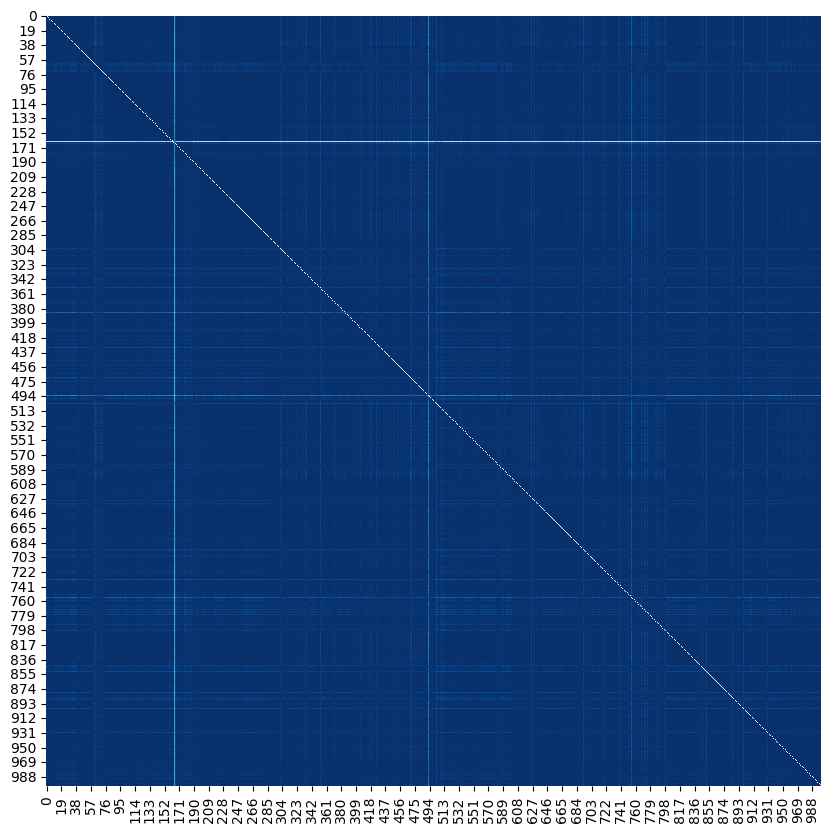

In [57]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(new, cmap='Blues', cbar=False)
plt.show()


In [63]:
labels=data3['label']

In [67]:
df = pd.DataFrame(new)
sim_df_names = df.set_index(labels.index)
sim_df_names.columns = labels.index
sim_df_names

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,0.000000,0.999581,0.998553,0.999663,0.996658,0.986370,0.992658,0.992093,0.999832,0.997365,...,0.944840,0.996902,0.995209,0.999158,0.998201,0.996231,0.999436,0.990629,0.999268,0.995295
1,0.999581,0.000000,0.997174,0.999233,0.995890,0.983952,0.989796,0.989373,0.999926,0.995996,...,0.939337,0.995740,0.994091,0.997817,0.997097,0.994894,0.998889,0.987932,0.998553,0.993892
2,0.998553,0.997174,0.000000,0.997164,0.999029,0.993551,0.997683,0.997402,0.997600,0.999748,...,0.960986,0.999447,0.998532,0.999858,0.999824,0.999252,0.999541,0.996526,0.999711,0.998821
3,0.999663,0.999233,0.997164,0.000000,0.994265,0.982280,0.990205,0.989358,0.999603,0.995405,...,0.937559,0.994677,0.992435,0.998188,0.996446,0.993851,0.998249,0.987495,0.998018,0.992672
4,0.996658,0.995890,0.999029,0.994265,0.000000,0.995961,0.997311,0.997552,0.995904,0.999650,...,0.966108,0.999883,0.999795,0.998278,0.999556,0.999805,0.998838,0.997277,0.999000,0.999705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.996231,0.994894,0.999252,0.993851,0.999805,0.996896,0.998547,0.998693,0.995128,0.999865,...,0.969154,0.999960,0.999832,0.998480,0.999584,0.000000,0.998494,0.998400,0.998766,0.999943
996,0.999436,0.998889,0.999541,0.998249,0.998838,0.991080,0.995328,0.995098,0.999036,0.999096,...,0.954268,0.998925,0.997899,0.999588,0.999562,0.998494,0.000000,0.994126,0.999963,0.997899
997,0.990629,0.987932,0.996526,0.987495,0.997277,0.999234,0.999633,0.999877,0.988550,0.997819,...,0.980663,0.997872,0.998276,0.995179,0.996765,0.998400,0.994126,0.000000,0.994775,0.998767
998,0.999268,0.998553,0.999711,0.998018,0.999000,0.991799,0.995960,0.995724,0.998747,0.999339,...,0.956018,0.999132,0.998142,0.999684,0.999678,0.998766,0.999963,0.994775,0.000000,0.998232


In [65]:
def find_similar_songs(name):
    # Find songs most similar to another song
    series = sim_df_names[name].sort_values(ascending = False)
    
    # Remove cosine similarity == 1 (songs will always have the best match with themselves)
    series = series.drop(name)
    
    # Display the 5 top matches 
    print("\n*******\nSimilar songs to ", name)
    print(series.head(5))

In [ ]:
name2num={}

data=data3['filename']
# print(data)
for i in range(len(data)):
#     print(i)
    name2num[i]=data[i]
    
print(name2num)

In [95]:
index_series = pd.Series(name2num)
sim_df_names.index = index_series
sim_df_names.columns=index_series

In [96]:
sim_df_names

,blues.00000.wav,blues.00001.wav,blues.00002.wav,blues.00003.wav,blues.00004.wav,blues.00005.wav,blues.00006.wav,blues.00007.wav,blues.00008.wav,blues.00009.wav,...,rock.00090.wav,rock.00091.wav,rock.00092.wav,rock.00093.wav,rock.00094.wav,rock.00095.wav,rock.00096.wav,rock.00097.wav,rock.00098.wav,rock.00099.wav
blues.00000.wav,0.000000,0.999581,0.998553,0.999663,0.996658,0.986370,0.992658,0.992093,0.999832,0.997365,...,0.944840,0.996902,0.995209,0.999158,0.998201,0.996231,0.999436,0.990629,0.999268,0.995295
blues.00001.wav,0.999581,0.000000,0.997174,0.999233,0.995890,0.983952,0.989796,0.989373,0.999926,0.995996,...,0.939337,0.995740,0.994091,0.997817,0.997097,0.994894,0.998889,0.987932,0.998553,0.993892
blues.00002.wav,0.998553,0.997174,0.000000,0.997164,0.999029,0.993551,0.997683,0.997402,0.997600,0.999748,...,0.960986,0.999447,0.998532,0.999858,0.999824,0.999252,0.999541,0.996526,0.999711,0.998821
blues.00003.wav,0.999663,0.999233,0.997164,0.000000,0.994265,0.982280,0.990205,0.989358,0.999603,0.995405,...,0.937559,0.994677,0.992435,0.998188,0.996446,0.993851,0.998249,0.987495,0.998018,0.992672
blues.00004.wav,0.996658,0.995890,0.999029,0.994265,0.000000,0.995961,0.997311,0.997552,0.995904,0.999650,...,0.966108,0.999883,0.999795,0.998278,0.999556,0.999805,0.998838,0.997277,0.999000,0.999705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rock.00095.wav,0.996231,0.994894,0.999252,0.993851,0.999805,0.996896,0.998547,0.998693,0.995128,0.999865,...,0.969154,0.999960,0.999832,0.998480,0.999584,0.000000,0.998494,0.998400,0.998766,0.999943
rock.00096.wav,0.999436,0.998889,0.999541,0.998249,0.998838,0.991080,0.995328,0.995098,0.999036,0.999096,...,0.954268,0.998925,0.997899,0.999588,0.999562,0.998494,0.000000,0.994126,0.999963,0.997899
rock.00097.wav,0.990629,0.987932,0.996526,0.987495,0.997277,0.999234,0.999633,0.999877,0.988550,0.997819,...,0.980663,0.997872,0.998276,0.995179,0.996765,0.998400,0.994126,0.000000,0.994775,0.998767
rock.00098.wav,0.999268,0.998553,0.999711,0.998018,0.999000,0.991799,0.995960,0.995724,0.998747,0.999339,...,0.956018,0.999132,0.998142,0.999684,0.999678,0.998766,0.999963,0.994775,0.000000,0.998232


In [98]:
general_path="/kaggle/input/gtzan-dataset-music-genre-classification/Data"

In [101]:
find_similar_songs('pop.00019.wav') 

ipd.Audio(f'{general_path}/genres_original/reggae/reggae.00086.wav ')


*******
Similar songs to  pop.00019.wav
reggae.00086.wav    0.999998
pop.00076.wav       0.999995
reggae.00050.wav    0.999991
pop.00038.wav       0.999991
pop.00068.wav       0.999987
Name: pop.00019.wav, dtype: float64


ValueError: rate must be specified when data is a numpy array or list of audio samples.

{0: 'blues.00000.wav', 1: 'blues.00001.wav', 2: 'blues.00002.wav', 3: 'blues.00003.wav', 4: 'blues.00004.wav', 5: 'blues.00005.wav', 6: 'blues.00006.wav', 7: 'blues.00007.wav', 8: 'blues.00008.wav', 9: 'blues.00009.wav', 10: 'blues.00010.wav', 11: 'blues.00011.wav', 12: 'blues.00012.wav', 13: 'blues.00013.wav', 14: 'blues.00014.wav', 15: 'blues.00015.wav', 16: 'blues.00016.wav', 17: 'blues.00017.wav', 18: 'blues.00018.wav', 19: 'blues.00019.wav', 20: 'blues.00020.wav', 21: 'blues.00021.wav', 22: 'blues.00022.wav', 23: 'blues.00023.wav', 24: 'blues.00024.wav', 25: 'blues.00025.wav', 26: 'blues.00026.wav', 27: 'blues.00027.wav', 28: 'blues.00028.wav', 29: 'blues.00029.wav', 30: 'blues.00030.wav', 31: 'blues.00031.wav', 32: 'blues.00032.wav', 33: 'blues.00033.wav', 34: 'blues.00034.wav', 35: 'blues.00035.wav', 36: 'blues.00036.wav', 37: 'blues.00037.wav', 38: 'blues.00038.wav', 39: 'blues.00039.wav', 40: 'blues.00040.wav', 41: 'blues.00041.wav', 42: 'blues.00042.wav', 43: 'blues.00043.wav

In [37]:
import torch
from torch import nn
import torchvision 
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor

In [140]:
data = pd.read_csv('/kaggle/input/gtzan-dataset-music-genre-classification/Data/features_3_sec.csv')
data

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9985,rock.00099.5.wav,66149,0.349126,0.080515,0.050019,0.000097,1499.083005,164266.886443,1718.707215,85931.574523,...,42.485981,-9.094270,38.326839,-4.246976,31.049839,-5.625813,48.804092,1.818823,38.966969,rock
9986,rock.00099.6.wav,66149,0.372564,0.082626,0.057897,0.000088,1847.965128,281054.935973,1906.468492,99727.037054,...,32.415203,-12.375726,66.418587,-3.081278,54.414265,-11.960546,63.452255,0.428857,18.697033,rock
9987,rock.00099.7.wav,66149,0.347481,0.089019,0.052403,0.000701,1346.157659,662956.246325,1561.859087,138762.841945,...,78.228149,-2.524483,21.778994,4.809936,25.980829,1.775686,48.582378,-0.299545,41.586990,rock
9988,rock.00099.8.wav,66149,0.387527,0.084815,0.066430,0.000320,2084.515327,203891.039161,2018.366254,22860.992562,...,28.323744,-5.363541,17.209942,6.462601,21.442928,2.354765,24.843613,0.675824,12.787750,rock


In [141]:
data = data.drop(['length'], axis=1)
data = data.drop(['filename'], axis=1)

In [142]:
data

,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,3714.560359,1.080790e+06,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,3869.682242,6.722448e+05,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,3997.639160,7.907127e+05,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,3568.300218,9.216524e+05,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,3469.992864,6.102111e+05,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9985,0.349126,0.080515,0.050019,0.000097,1499.083005,164266.886443,1718.707215,85931.574523,3015.559458,8.479527e+05,...,42.485981,-9.094270,38.326839,-4.246976,31.049839,-5.625813,48.804092,1.818823,38.966969,rock
9986,0.372564,0.082626,0.057897,0.000088,1847.965128,281054.935973,1906.468492,99727.037054,3746.694524,1.170890e+06,...,32.415203,-12.375726,66.418587,-3.081278,54.414265,-11.960546,63.452255,0.428857,18.697033,rock
9987,0.347481,0.089019,0.052403,0.000701,1346.157659,662956.246325,1561.859087,138762.841945,2442.362154,2.602871e+06,...,78.228149,-2.524483,21.778994,4.809936,25.980829,1.775686,48.582378,-0.299545,41.586990,rock
9988,0.387527,0.084815,0.066430,0.000320,2084.515327,203891.039161,2018.366254,22860.992562,4313.266226,4.968878e+05,...,28.323744,-5.363541,17.209942,6.462601,21.442928,2.354765,24.843613,0.675824,12.787750,rock


In [143]:
classes = data['label'].unique()
label_to_number={}
i=0
for name in classes:
    label_to_number[name]=i
    i+=1
data['label']=data['label'].map(label_to_number)

In [144]:
data['label']

0       0
1       0
2       0
3       0
4       0
       ..
9985    9
9986    9
9987    9
9988    9
9989    9
Name: label, Length: 9990, dtype: int64

In [79]:
#run to get the labels back from numbers
num2name={}
for i in range(len(classes)):
    num2name[i]=classes[i]
print(num2name)

{0: 'disco', 1: 'classical', 2: 'pop', 3: 'reggae', 4: 'metal', 5: 'country', 6: 'jazz', 7: 'blues', 8: 'hiphop', 9: 'rock'}


In [145]:
data_s = data.sample(frac=1, random_state=42).reset_index(drop=True)
print(data_s)

      chroma_stft_mean  chroma_stft_var  rms_mean   rms_var  \
0             0.404232         0.096884  0.090223  0.000638   
1             0.243589         0.084304  0.090146  0.000930   
2             0.355097         0.086465  0.130576  0.001197   
3             0.387297         0.092417  0.149871  0.005382   
4             0.419387         0.079487  0.153464  0.001511   
...                ...              ...       ...       ...   
9985          0.267750         0.095907  0.097862  0.003840   
9986          0.248258         0.081754  0.041260  0.000109   
9987          0.240019         0.093735  0.083758  0.002298   
9988          0.365543         0.092261  0.108228  0.002294   
9989          0.424610         0.080515  0.173596  0.001938   

      spectral_centroid_mean  spectral_centroid_var  spectral_bandwidth_mean  \
0                1416.001997           4.652689e+05              1973.083395   
1                1206.214018           4.888347e+04              1523.543854   
2  

In [146]:
X = data_s.iloc[:,:-1]
y  = data_s.iloc[:,-1]
print(y)

0       4
1       5
2       0
3       0
4       6
       ..
9985    5
9986    5
9987    5
9988    0
9989    7
Name: label, Length: 9990, dtype: int64


In [117]:
# X.dtypes.sample(20)
# y = y.astype(np.float64)

In [147]:
print(y)

0       4
1       5
2       0
3       0
4       6
       ..
9985    5
9986    5
9987    5
9988    0
9989    7
Name: label, Length: 9990, dtype: int64


In [148]:
train_size = int(0.8 * len(data_f))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [149]:
X_train=torch.tensor(X_train.values) 
X_test=torch.tensor(X_test.values)
y_train=torch.tensor(y_train.values)
y_test=torch.tensor(y_test.values)

In [166]:
X_train = X_train.float()
y_train = y_train.float()
X_test = X_test.float()
y_test = y_test.float()

In [157]:
if torch.cuda.is_available():
    device = torch.device(type='cuda', index=0)
else:
    device = torch.device(type='cpu')

In [203]:
class NeuralNetwork(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.FF_net=nn.Sequential(
                                  nn.Linear(57,32),
                                  nn.ReLU(),
                                  nn.BatchNorm1d(32),
                                  nn.Linear(32,10),
                                  nn.ReLU())
    def forward(self, X_train):
#         X_train=self.flatten(X_train)
        logits = self.FF_net(X_train)
        return logits

model = NeuralNetwork().to(device)
model.eval()
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (FF_net): Sequential(
    (0): Linear(in_features=57, out_features=32, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=32, out_features=10, bias=True)
    (4): ReLU()
  )
)


In [159]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [160]:
print(X_train.shape)

torch.Size([7992, 57])


In [194]:
batch_size=5
training_dataset = TensorDataset(X_train, y_train)
testing_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=False)

In [131]:
# num_epochs = 10
# for epoch in range(num_epochs):
    
#     model.train()
#     running_loss = 0.0 
#     for inputs, labels in train_loader:
#         optimizer.zero_grad()
#         outputs=model(inputs)
#         loss = loss_fn(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         running_loss+=loss.item()*input.size(0)
#     epoch_loss = running_loss/len(train_loader.dataset)
#     print(f"Epoch{epoch+1}/{num_epochs}, Loss: {epoch_loss} ----------------------------------------------------")

# model.eval()
# y_pred = []
# with torch.no_grad():
#     for inputs, labels in test_loader:
#         outputs = model(inputs)
#         _, predicted = torch.max(outputs, 1)
#         y_pred.extend(predicted.cpu().numpy())

# accuracy = accuracy_score(y_test, y_pred)
# print(f"Accuracy: {accuracy:}")

In [207]:
def train_one_epoch(dataloader, model, loss_fn, optimizer):
    model.train()
    track_loss=0
    correct=0
    
    for i, (X,y) in enumerate(dataloader):
        X = X.unsqueeze(0)
        X = X.to(device)
        y = y.to(device)
        model.eval()
        pred=model(X)
        loss=loss_fn(pred, y)
        
        track_loss+=loss.item()
        correct+=(torch.argmax(pred, dim=1)==y).type(torch.float).sum().item()
        
        running_loss=round(track_loss/(i+(X.shape[0]/batch_size)),2) 
        running_acc=round((correct)/(i*batch_size+X.shape[0]),2)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        if i%100==0:
            print("Batch:", i+1, "/",len(dataloader),"Running Loss:",running_loss, "Running Accuracy:",running_acc)
            
def test(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss = 0
    test_acc = 0
    with torch.no_grad():
        for X,y in dataloader:
            X = X.to(device)
            y = y.to(device)
            pred = model(X)
            loss = loss_fn(pred, y)
            test_loss+=loss.item()
            test_acc+=(torch.argmax(pred, dim=1)==y).type(torch.float).sum().item()
            
    test_loss/=num_batches
    test_acc/=size
    print(f"Accuracy: ", (100*test_acc), "Test Loss: ", (test_loss), "\n")
            

In [208]:
epochs = 20
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_one_epoch(training_dataset, model, loss_fn, optimizer)
    test(testing_dataset, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------


ValueError: Expected input batch_size (1) to match target batch_size (0).